In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
CURRENT_DIRECTORY =  os.getcwd()
SRC_DIRECTORY = Path(CURRENT_DIRECTORY).parents[1]
print(SRC_DIRECTORY)

BASE_DATASET_PATH = Path(SRC_DIRECTORY).parents[0]
BASE_DATASET_PATH = BASE_DATASET_PATH / "datasets"
print(BASE_DATASET_PATH)

/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/src
/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/datasets


#### Get subzone data

In [3]:

def get_subzone_data(year: int):
    """
    Args
    ------
    year: int
        year of the subzones you want (2019, 2014, 2008)

    Returns
    ------
    Subzone dataframe containing the subzone names, planning area names and areas of points of interest.
    """

    year = str(year)

    subzones_filepath = Path(BASE_DATASET_PATH / f"singapore_data/data_gov/masterplan_{year}/subzone_classifications_{year}.csv")
    subzones = pd.read_csv(subzones_filepath)

    subzones = subzones.map(lambda s: s.lower() if isinstance(s, str) else s)
    return subzones

In [4]:
subzone_df = get_subzone_data(2014)
subzone_df.head(3)

,subzone_n,pln_area_n,beach_area,business_2,educational_institution,utility,special_use,waterbody,port_/_airport,park,...,reserve_site,white,place_of_worship,business_2_-_white,hotel,residential_/_institution,business_park_-_white,business_park,agriculture,pri_classification
0,ang mo kio town centre,ang mo kio,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.00000,...,3618.378339,0.0,3158.691818,0.0,0.0,0.0,0.0,0.0,0.0,residential
1,cheng san,ang mo kio,0.0,0.0,69353.966728,5449.975328,0.0,0.0,0.0,0.00000,...,66034.996250,0.0,2670.252332,0.0,0.0,0.0,0.0,0.0,0.0,residential
2,chong boon,ang mo kio,0.0,0.0,100775.355941,3683.124722,0.0,0.0,0.0,30024.94591,...,0.000000,0.0,3709.155602,0.0,0.0,0.0,0.0,0.0,0.0,residential


#### Resident Density

In [5]:
def get_resident_data(year):
    """
    Args
    ------
    year: int
        year of the resident data (resident numbers and age group) you want (2020, 2015, 2010)

    Returns
    ------
    Dataframe containing the subzone names, planning area names and resident numbers and age group.
    """
    residential_filepath = Path(BASE_DATASET_PATH / f"singapore_data/cleaned_data/{year}_age_group_planning_area_subzone.xlsx")

    residential_data = pd.read_excel(residential_filepath, sheet_name = "subzone")
    residential_data["planning_area"] = residential_data["planning_area"].ffill()

    return residential_data

In [6]:
resident_df = get_resident_data(2015)
resident_df

,planning_area,subzone,total,total_0_4,total_5_9,total_10_14,total_15_19,total_20_24,total_25_29,total_30_34,...,females_45_49,females_50_54,females_55_59,females_60_64,females_65_69,females_70_74,females_75_79,females_80_84,females_85andover,total_above_60
0,total,total,3902690,183580,204450,214390,242900,264130,271030,290620,...,153810,156630,147200,120830,93730,54850,45090,30850,27660,700210
1,ang mo kio,total,174770,6790,7660,8290,9320,10310,11170,12250,...,6660,7010,7120,6940,5810,3600,2800,1910,1520,41390
2,ang mo kio,ang mo kio town centre,5020,260,280,320,280,260,310,370,...,210,170,170,160,150,80,70,40,40,940
3,ang mo kio,cheng san,29770,1290,1180,1290,1400,1570,1830,2490,...,1110,1140,1220,1270,970,580,420,280,260,6950
4,ang mo kio,chong boon,27900,910,1100,1180,1370,1520,1800,1980,...,1080,1120,1160,1200,1050,690,500,310,240,7330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,yishun,springleaf,3880,140,170,220,260,350,290,190,...,140,170,160,150,120,70,40,30,30,860
375,yishun,yishun central,1490,50,70,50,110,150,120,120,...,70,70,70,60,30,20,20,10,10,270
376,yishun,yishun east,54880,4580,3210,2850,3110,3600,5010,6470,...,1880,1970,1670,1260,920,410,320,230,160,6290
377,yishun,yishun south,38840,1430,1770,1980,2350,3120,3290,2700,...,1490,1860,1740,1300,900,490,360,270,240,6820


In [23]:
def check_for_missing_subzone_pln_area(subzone_df, demographic_df):
    # check if the planning area and subzone name of both datasets match

    # 1. Perform the left join
    # subzones_2019 is the 'left' table because it contains all pairs
    check_df = pd.merge(
        subzone_df, 
        demographic_df, 
        left_on=['subzone_n', 'pln_area_n'], 
        right_on=['subzone', 'planning_area'], 
        how='left',
        indicator=True
    )

    # 2. Identify the pairs that are MISSING in residential_df
    missing_in_res = check_df[check_df['_merge'] == 'left_only']

    # 3. Identify the pairs that MATCH in both
    matching_pairs = check_df[check_df['_merge'] == 'both']

    print(f"Total pairs in Subzones df: {len(subzone_df)}")
    print(f"Matches found: {len(matching_pairs)}")
    print(f"Pairs missing in Residential df: {len(missing_in_res)}")
    if len(missing_in_res) != 0:
        print(f"Pairs missing in Residential df: {missing_in_res}")

In [24]:
check_for_missing_subzone_pln_area(subzone_df, resident_df)

Total pairs in Subzones df: 323
Matches found: 323
Pairs missing in Residential df: 0


Density per hectare = $\frac{residential\ number \times 10000}{Area\ in \ m^2}$

In [8]:
def calculate_density(subzone_df, resident_df):
    # calculate the residential density of each subzone

    # left join to keep all subzones from the 2019 master list
    merged_total_density_df = pd.merge(
        subzone_df, 
        resident_df[['subzone', 'planning_area', 'total', 'total_above_60']], 
        left_on=['subzone_n', 'pln_area_n'], 
        right_on=['subzone', 'planning_area'], 
        how='left'
    )
    # We fill NaN totals with 0 so the calculation doesn't fail
    merged_total_density_df['total'] = merged_total_density_df['total'].fillna(0)
    merged_total_density_df['total_above_60'] = merged_total_density_df['total_above_60'].fillna(0)

    # Identify and sum all columns that contain 'residential' in the name
    residential_cols = [col for col in merged_total_density_df.columns if 'residential' in col]
    merged_total_density_df['total_residential_area'] = merged_total_density_df[residential_cols].sum(axis=1)

    # Calculate Density per Hectare
    # Formula: (residential number * 10000) / Area in m2
    merged_total_density_df['density_per_ha'] = (merged_total_density_df['total'] * 10000) / merged_total_density_df['total_residential_area']

    # Replace infinity values if area was 0
    merged_total_density_df['density_per_ha'] = merged_total_density_df['density_per_ha'].replace([np.inf, -np.inf], 0)
    # display(merged_total_density_df[['pln_area_n', 'subzone_n', 'total', 'total_residential_area', 'density_per_ha']].head())
    
    return merged_total_density_df

In [9]:
merged_total_density_df = calculate_density(subzone_df, resident_df)

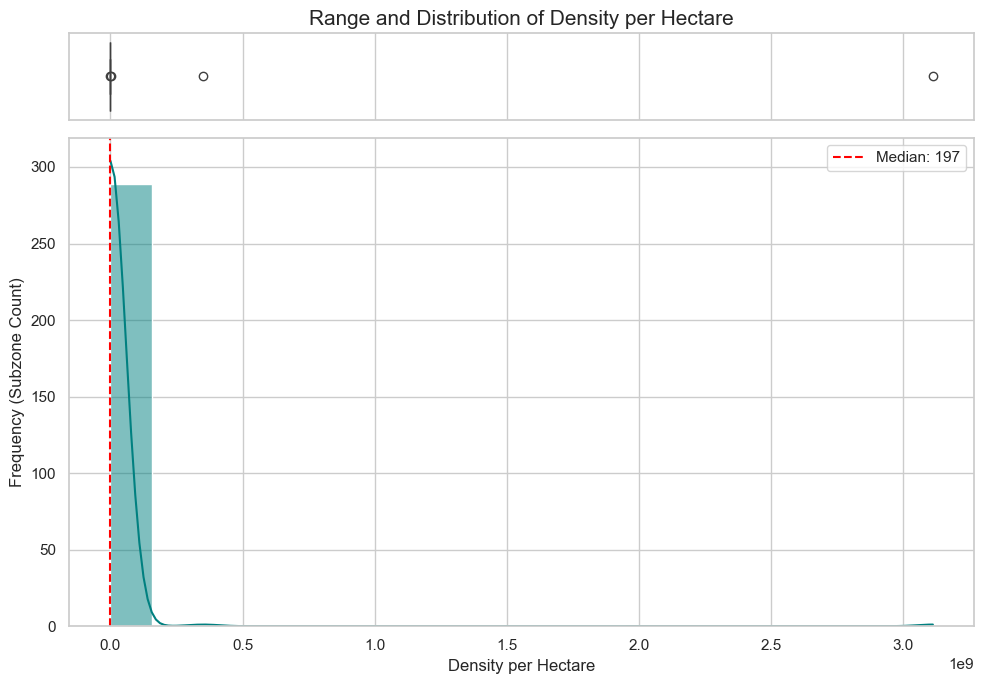

In [10]:
def display_distribution(df, characteristic: str):
    # Set the style
    sns.set_theme(style="whitegrid")

    # Create a figure with two subplots (1 row, 2 columns - or stacked)
    # We will use a "Gridspec" style approach for a top-bottom view
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 7))

    # 1. Plot the Range (Boxplot) on the top axis
    sns.boxplot(x=df["density_per_ha"], ax=ax_box, color="lightseagreen")
    ax_box.set(xlabel='') # Hide xlabel for the top plot
    ax_box.set_title(f'Range and Distribution of {characteristic}', fontsize=15)

    # 2. Plot the Distribution (Histogram + KDE) on the bottom axis
    sns.histplot(df["density_per_ha"], ax=ax_hist, kde=True, color="teal", bins=20)

    # Labeling
    plt.xlabel(f'{characteristic}', fontsize=12)
    plt.ylabel('Frequency (Subzone Count)', fontsize=12)

    # Add a vertical line for the Median on the histogram
    median_val = df["density_per_ha"].median()
    ax_hist.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:,.0f}')
    plt.legend()

    plt.tight_layout()
    plt.show()

display_distribution(merged_total_density_df, "Density per Hectare")

In [11]:
merged_total_density_df["density_per_ha"] = merged_total_density_df["density_per_ha"].fillna(0)
df = merged_total_density_df.sort_values("density_per_ha", ascending = False)
df[['pln_area_n', 'subzone_n', 'total', 'total_residential_area', 'density_per_ha']].head(10)

,pln_area_n,subzone_n,total,total_residential_area,density_per_ha
175,outram,people's park,390,0.001253,3.113257e+09
208,queenstown,national university of s'pore,360,0.010230,3.518961e+08
68,central water catchment,central water catchment,10,0.184207,5.428676e+05
224,rochor,little india,3850,31678.627708,1.215330e+03
173,outram,chinatown,11880,121098.901133,9.810163e+02
132,jurong west,wenya,8610,101520.563860,8.481040e+02
136,kallang,crawford,9740,121057.455377,8.045766e+02
172,outram,china square,1590,20798.118907,7.644922e+02
71,changi,changi west,1740,23721.594870,7.335089e+02
128,jurong west,jurong west central,68200,935811.205248,7.287795e+02


Encoding resident density: 
- 0 residents -> 0
- 0 to 10 residents -> 1
- 10 to 50 residents -> 2
- 50 to 100 residents -> 3
- 100 to 1000 residents -> 4

There are 3 points of outlier that needs to be checked.
- people's park (0.09135 $km^2$)
- national university of s'pore (1.753 $km^2$)
- little india (0.2783 $km^2$)

landsizes base on: https://www.citypopulation.de/en/singapore/admin/

There are multiple subzones with residents but no recorded residential areas. They will be categorised as such:
1. subzones with 10 or less residents: 0 to 10 residents
2. subzones with 10 to 50 residents: 10 to 50 residents
3. subzones with 50 or more residents: 50 to 100 residents

Subzones with more than 100 residents but with no recorded residential areas will be assigned to the 50 to 100 residents category. These subzones have less established residential areas so its characteristics might differ from subzones with larger residential areas. This is also to avoid affecting the accuracy of prediction for subzones with more than 1000 residents.

People's park and national university of s'pore will be assigned to the 50 to 100 residents category. This is because both has a resident size of <300, People's park residents are mostly located within the people's park complex and national univeristy of singapore's residents would be students and staff living in accomodations throughout the university. 

little india will be assigned to the 100 to 1000 residents category as the subzone has a small area but more than 3000 residents

For *2015* subzone data, resident density for central water catchment will be subzones with 10 to 50 residents. Based on the total resident numbers for the subzone. 

In [12]:
def encode_resident_density(bins, labels, df, manual_overrides):
    # encode resident density base on the given bins and labels
    df["resident_density_encoding"] = pd.cut(df["density_per_ha"], bins = bins, labels = labels).astype(int)

    # Refined Logic for subzones with 0 density but >0 total residents
    cond1 = (df["resident_density_encoding"] == 0) & (df["total"] > 0) & (df["total"] <= 10)
    cond2 = (df["resident_density_encoding"] == 0) & (df["total"] > 10) & (df["total"] <= 50)
    cond3 = (df["resident_density_encoding"] == 0) & (df["total"] > 50)

    # Define the values to assign for each condition
    choices = [1, 2, 3]

    # Apply the correction
    df["resident_density_encoding"] = np.select(
        [cond1, cond2, cond3], 
        choices, 
        default=df["resident_density_encoding"]
    )

    # apply the manual mapping
    for subzone, new_encoding in manual_overrides.items():
        condition = df['subzone'].str.lower() == subzone.lower()
        df.loc[condition, "resident_density_encoding"] = new_encoding

    return df

In [13]:
"""
0 residents -> 0
0 to 10 residents -> 1
10 to 50 residents -> 2
50 to 100 residents -> 3
100 to 1000 residents -> 4
"""
bins = [-0.1, 0, 10, 50, 100, float('inf')]
labels = [0, 1, 2, 3, 4]

# key is the subzone name, value is the density encoding you want to override with
density_manual_overrides = {
    "people's park": 3,
    "national university of s'pore": 3,
    "central water catchment": 2,
}

resident_density_df = encode_resident_density(bins, labels, merged_total_density_df, density_manual_overrides)

In [14]:
resident_density_df.head()

,subzone_n,pln_area_n,beach_area,business_2,educational_institution,utility,special_use,waterbody,port_/_airport,park,...,business_park,agriculture,pri_classification,subzone,planning_area,total,total_above_60,total_residential_area,density_per_ha,resident_density_encoding
0,ang mo kio town centre,ang mo kio,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,residential,ang mo kio town centre,ang mo kio,5020,940,220396.018840,227.771809,4
1,cheng san,ang mo kio,0.0,0.0,69353.966728,5449.975328,0.0,0.0,0.0,0.000000,...,0.0,0.0,residential,cheng san,ang mo kio,29770,6950,614590.310214,484.387721,4
2,chong boon,ang mo kio,0.0,0.0,100775.355941,3683.124722,0.0,0.0,0.0,30024.945910,...,0.0,0.0,residential,chong boon,ang mo kio,27900,7330,559216.103689,498.912671,4
3,kebun bahru,ang mo kio,0.0,0.0,81758.997618,0.000000,0.0,0.0,0.0,219653.986475,...,0.0,0.0,residential,kebun bahru,ang mo kio,23910,6090,564109.261312,423.854059,4
4,sembawang hills,ang mo kio,0.0,0.0,0.000000,6863.003451,0.0,0.0,0.0,20815.432976,...,0.0,0.0,residential,sembawang hills,ang mo kio,6890,1550,557535.561775,123.579561,4


#### Proportion of Residents aged >60 per 1000 residents
proportion of above age 60 residents = $\frac{residents\ above\ 60}{total\ subzone\ residents} \times 1000$

In [15]:
def encode_above_60_proportion(df):
    df['above_60_proportion'] = (df['total_above_60'] / df['total']) * 1000

    # Replace infinity values if area was 0
    df['above_60_proportion'] = df['above_60_proportion'].replace([np.inf, -np.inf], 0)
    df["above_60_proportion"] = df["above_60_proportion"].fillna(0)

    return df


In [16]:
resident_above_60_df = encode_above_60_proportion(merged_total_density_df)
resident_above_60_df

,subzone_n,pln_area_n,beach_area,business_2,educational_institution,utility,special_use,waterbody,port_/_airport,park,...,agriculture,pri_classification,subzone,planning_area,total,total_above_60,total_residential_area,density_per_ha,resident_density_encoding,above_60_proportion
0,ang mo kio town centre,ang mo kio,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,residential,ang mo kio town centre,ang mo kio,5020,940,2.203960e+05,227.771809,4,187.250996
1,cheng san,ang mo kio,0.0,0.0,69353.966728,5449.975328,0.0,0.000000,0.0,0.000000,...,0.0,residential,cheng san,ang mo kio,29770,6950,6.145903e+05,484.387721,4,233.456500
2,chong boon,ang mo kio,0.0,0.0,100775.355941,3683.124722,0.0,0.000000,0.0,30024.945910,...,0.0,residential,chong boon,ang mo kio,27900,7330,5.592161e+05,498.912671,4,262.724014
3,kebun bahru,ang mo kio,0.0,0.0,81758.997618,0.000000,0.0,0.000000,0.0,219653.986475,...,0.0,residential,kebun bahru,ang mo kio,23910,6090,5.641093e+05,423.854059,4,254.705144
4,sembawang hills,ang mo kio,0.0,0.0,0.000000,6863.003451,0.0,0.000000,0.0,20815.432976,...,0.0,residential,sembawang hills,ang mo kio,6890,1550,5.575356e+05,123.579561,4,224.963716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318,springleaf,yishun,0.0,0.0,0.000000,0.000000,0.0,56373.160888,0.0,204196.146475,...,0.0,reserve site,springleaf,yishun,3880,860,3.549165e+05,109.321492,4,221.649485
319,yishun central,yishun,0.0,0.0,0.000000,1088.972646,0.0,47604.148194,0.0,36784.580729,...,0.0,reserve site,yishun central,yishun,1490,270,8.029561e+04,185.564325,4,181.208054
320,yishun east,yishun,0.0,0.0,138077.888015,0.000000,0.0,37420.359680,0.0,42917.797872,...,0.0,residential,yishun east,yishun,54880,6290,1.208867e+06,453.978633,4,114.613703
321,yishun south,yishun,0.0,0.0,89283.669700,0.000000,0.0,21652.821902,0.0,166223.114746,...,0.0,residential,yishun south,yishun,38840,6820,7.642254e+05,508.227052,4,175.592173


#### Ethnicity
Proportion of each ethnicity (chinses, malay, indian, others) per 1000 residents

In [17]:
def get_ethnicity_data(year: int):
    year = str(year)

    ethnicity_filepath = Path(BASE_DATASET_PATH / "singapore_data/cleaned_data/ethnicity_combined.xlsx")

    ethnicity_df = pd.read_excel(ethnicity_filepath, sheet_name = f"{year}")

    return ethnicity_df

In [21]:
ethnicity_df = get_ethnicity_data(2015)
ethnicity_df["planning_area"] = ethnicity_df["planning_area"].ffill()
ethnicity_df.head()

,planning_area,subzone,total,male_total,female_total,total_chinese,male_chinese,female_chinese,total_malays,male_malays,female_malays,total_indians,male_indians,female_indians,total_others,male_others,female_others
0,total,total,3902690,1916630,1986060,2900010,1415300,1484700,520920,259110,261820,354950,182300,172650,126810,59910,66900
1,ang mo kio,total,174770,84220,90550,143290,68860,74430,13060,6430,6640,14150,7050,7100,4270,1890,2390
2,ang mo kio,ang mo kio town centre,5020,2370,2640,4260,2020,2240,210,90,120,360,170,190,190,100,90
3,ang mo kio,cheng san,29770,14400,15370,24660,11890,12770,2140,1080,1060,2380,1210,1170,600,230,370
4,ang mo kio,chong boon,27900,13590,14310,22910,11150,11760,1950,950,1010,2400,1230,1170,630,260,370


In [ ]:
# check if there is any missing subzones for the ethnicity dataframe
check_for_missing_subzone_pln_area(subzone_df, ethnicity_df)

Total pairs in Subzones df: 323
Matches found: 323
Pairs missing in Residential df: 0


In [ ]:
def encode_ethnicity(subzone_df, ethnicity_df, columns_of_interest):

    columns_of_interest += ["subzone", "planning_area"]

    # left join to keep all subzones from the 2019 master list
    merged_ethnicity_density_df = pd.merge(
        subzone_df, 
        ethnicity_df[columns_of_interest], 
        left_on=['subzone_n', 'pln_area_n'],
        right_on=['subzone', 'planning_area'],
        how='left'
    )
    # We fill NaN totals with 0 so the calculation doesn't fail
    merged_ethnicity_density_df[columns_of_interest] = merged_ethnicity_density_df[columns_of_interest].fillna(0)

    # Calculate proportion of ethnicity per 1000 residents
    merged_ethnicity_density_df['chinese_proportion'] = (merged_ethnicity_density_df['total_chinese'] / merged_ethnicity_density_df['total']) * 1000
    merged_ethnicity_density_df['malays_proportion'] = (merged_ethnicity_density_df['total_malays'] / merged_ethnicity_density_df['total']) * 1000
    merged_ethnicity_density_df['indians_proportion'] = (merged_ethnicity_density_df['total_indians']/ merged_ethnicity_density_df['total']) * 1000
    merged_ethnicity_density_df['others_proportion'] = (merged_ethnicity_density_df['total_others']/ merged_ethnicity_density_df['total']) * 1000

    return merged_ethnicity_density_df

In [27]:
columns_of_interest = ["total", "total_chinese", "total_malays", "total_indians", "total_others"]
merged_ethnicity_density_df = encode_ethnicity(subzone_df, ethnicity_df, columns_of_interest)
merged_ethnicity_density_df

,subzone_n,pln_area_n,beach_area,business_2,educational_institution,utility,special_use,waterbody,port_/_airport,park,...,planning_area,total,total_chinese,total_malays,total_indians,total_others,chinese_proportion,malays_proportion,indians_proportion,others_proportion
0,ang mo kio town centre,ang mo kio,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,ang mo kio,5020,4260,210,360,190,848.605578,41.832669,71.713147,37.848606
1,cheng san,ang mo kio,0.0,0.0,69353.966728,5449.975328,0.0,0.000000,0.0,0.000000,...,ang mo kio,29770,24660,2140,2380,600,828.350689,71.884447,79.946255,20.154518
2,chong boon,ang mo kio,0.0,0.0,100775.355941,3683.124722,0.0,0.000000,0.0,30024.945910,...,ang mo kio,27900,22910,1950,2400,630,821.146953,69.892473,86.021505,22.580645
3,kebun bahru,ang mo kio,0.0,0.0,81758.997618,0.000000,0.0,0.000000,0.0,219653.986475,...,ang mo kio,23910,19210,2200,1910,590,803.429527,92.011711,79.882894,24.675868
4,sembawang hills,ang mo kio,0.0,0.0,0.000000,6863.003451,0.0,0.000000,0.0,20815.432976,...,ang mo kio,6890,6080,100,500,220,882.438316,14.513788,72.568940,31.930334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318,springleaf,yishun,0.0,0.0,0.000000,0.000000,0.0,56373.160888,0.0,204196.146475,...,yishun,3880,3560,30,190,100,917.525773,7.731959,48.969072,25.773196
319,yishun central,yishun,0.0,0.0,0.000000,1088.972646,0.0,47604.148194,0.0,36784.580729,...,yishun,1490,1200,140,130,30,805.369128,93.959732,87.248322,20.134228
320,yishun east,yishun,0.0,0.0,138077.888015,0.000000,0.0,37420.359680,0.0,42917.797872,...,yishun,54880,37680,10500,5350,1340,686.588921,191.326531,97.485423,24.416910
321,yishun south,yishun,0.0,0.0,89283.669700,0.000000,0.0,21652.821902,0.0,166223.114746,...,yishun,38840,28880,4960,4010,990,743.563337,127.703399,103.244078,25.489186


#### Workplace classification

In [33]:
def get_landuse_dataset(year: int):
    year = str(year)

    landuse_filepath = Path(BASE_DATASET_PATH / f"singapore_data/data_gov/masterplan_{year}/subzone_classifications_{year}.csv")
    landuse_df = pd.read_csv(landuse_filepath)

    return landuse_df

In [34]:
landuse_df = get_landuse_dataset(2014)
landuse_df

,subzone_n,pln_area_n,beach_area,business_2,educational_institution,utility,special_use,waterbody,port_/_airport,park,...,reserve_site,white,place_of_worship,business_2_-_white,hotel,residential_/_institution,business_park_-_white,business_park,agriculture,pri_classification
0,ANG MO KIO TOWN CENTRE,ANG MO KIO,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,3.618378e+03,0.0,3158.691818,0.0,0.0,0.0,0.0,0.0,0.0,RESIDENTIAL
1,CHENG SAN,ANG MO KIO,0.0,0.0,69353.966728,5449.975328,0.0,0.000000,0.0,0.000000,...,6.603500e+04,0.0,2670.252332,0.0,0.0,0.0,0.0,0.0,0.0,RESIDENTIAL
2,CHONG BOON,ANG MO KIO,0.0,0.0,100775.355941,3683.124722,0.0,0.000000,0.0,30024.945910,...,0.000000e+00,0.0,3709.155602,0.0,0.0,0.0,0.0,0.0,0.0,RESIDENTIAL
3,KEBUN BAHRU,ANG MO KIO,0.0,0.0,81758.997618,0.000000,0.0,0.000000,0.0,219653.986475,...,0.000000e+00,0.0,2325.137686,0.0,0.0,0.0,0.0,0.0,0.0,RESIDENTIAL
4,SEMBAWANG HILLS,ANG MO KIO,0.0,0.0,0.000000,6863.003451,0.0,0.000000,0.0,20815.432976,...,6.499522e+04,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,RESIDENTIAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318,SPRINGLEAF,YISHUN,0.0,0.0,0.000000,0.000000,0.0,56373.160888,0.0,204196.146475,...,1.220528e+06,0.0,7532.081767,0.0,0.0,0.0,0.0,0.0,0.0,RESERVE SITE
319,YISHUN CENTRAL,YISHUN,0.0,0.0,0.000000,1088.972646,0.0,47604.148194,0.0,36784.580729,...,1.188969e+05,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,RESERVE SITE
320,YISHUN EAST,YISHUN,0.0,0.0,138077.888015,0.000000,0.0,37420.359680,0.0,42917.797872,...,5.398959e+04,0.0,5189.524083,0.0,0.0,0.0,0.0,0.0,0.0,RESIDENTIAL
321,YISHUN SOUTH,YISHUN,0.0,0.0,89283.669700,0.000000,0.0,21652.821902,0.0,166223.114746,...,5.378722e+03,0.0,1317.256952,0.0,0.0,0.0,0.0,0.0,0.0,RESIDENTIAL


There are 3 types of workplace classification in singapore.
- business 1: Clean industry, light industry, public utilities (logistics, warehousing, technology, research)
- business 2: Special industries involving industrial machinery, shipbuilding and repairing (heavy industries)
- business park: blend of industrial and office spaces

Each of these 3 workplaces could also be classified as white sites:

Which are areas used for commercial, hotel, residential, office, recreational club. As the number of workplaces that are labelled as white sites are few, they will be combined with their respective workplace types (eg: business 1 will combine with business 1 white)

Additionally, subzones with workplace areas smaller than 1000 $m^2$ will not be included. Reason is that a workplace that is too small would not have many workers in there.

references: 
- https://propertyreviewsg.com/ura-masterplan-zoning-interpretation/
- https://www.sgindustrialgroup.com/post/the-difference-between-different-industrial-property-classes

In [ ]:
def determine_workplace_type(landuse_df, columns_of_interest):

    workplace_cols = [col for col in landuse_df.columns if 'business' in col]
    columns_of_interest += workplace_cols
    workplace_df = landuse_df[columns_of_interest].copy()

    workplace_df['pln_area_n'] = workplace_df['pln_area_n'].astype(str).str.strip().str.lower()
    workplace_df['subzone_n'] = workplace_df['subzone_n'].astype(str).str.strip().str.lower()

    workplace_df[workplace_cols] = workplace_df[workplace_cols].fillna(0)

    # group and Encode (Sum of workplace areas must be > 1000, else encode as 0)
    # sum the "White" and "Non-White" variants for each category
    workplace_df["business_1_encoding"] = (
        (workplace_df['business_1'] + workplace_df['business_1_-_white']) > 1000
    ).astype(int)
    workplace_df["business_2_encoding"] = (
        (workplace_df['business_2'] + workplace_df['business_2_-_white']) > 1000
    ).astype(int)
    workplace_df["business_park_encoding"] = (
        (workplace_df['business_park'] + workplace_df['business_park_-_white']) > 1000
    ).astype(int)

    return workplace_df

In [40]:
columns_of_interest = ["subzone_n", "pln_area_n", "pri_classification"]

workplace_df = determine_workplace_type(landuse_df, columns_of_interest)
workplace_df.head()

,subzone_n,pln_area_n,pri_classification,business_2,business_1_-_white,business_1,business_2_-_white,business_park_-_white,business_park,business_1_encoding,business_2_encoding,business_park_encoding
0,ang mo kio town centre,ang mo kio,RESIDENTIAL,0.0,0.0,0.000000,0.0,0.0,0.0,0,0,0
1,cheng san,ang mo kio,RESIDENTIAL,0.0,0.0,0.000000,0.0,0.0,0.0,0,0,0
2,chong boon,ang mo kio,RESIDENTIAL,0.0,0.0,161265.128547,0.0,0.0,0.0,1,0,0
3,kebun bahru,ang mo kio,RESIDENTIAL,0.0,0.0,0.000000,0.0,0.0,0.0,0,0,0
4,sembawang hills,ang mo kio,RESIDENTIAL,0.0,0.0,0.000000,0.0,0.0,0.0,0,0,0


#### Proportion of lower education level residents per 1000
In the Prediction model for future OHCAs based on geospatial and demogrpahic data paper, lower educational level was defined as "highest completed educational level being grade school, high school, vocational training or unknown educational level"

Lower education in Singapore's context would be post secondary (non-tertiary) education and below. 
#### Data.gov only has highest qualification attained by planning area, no subzone information could be found

In [46]:
def get_lower_education_dataset(year: int):
    year = str(year)
    education = Path(BASE_DATASET_PATH / "singapore_data/cleaned_data/education_combined.xlsx")
    education_df = pd.read_excel(education, sheet_name = year)

    return education_df

In [47]:
education_df = get_lower_education_dataset(2015)
education_df

,planning_area,total,no_qualification,pri,lower_sec,sec,post_sec_(non-tertiary),poly_diploma,professional_qualification_&_other_diploma,uni
0,total,2948500,368100,203400,236500,544800,304000,268100,215700,807900
1,ang mo kio,145200,23900,13400,13300,24600,13600,11100,10100,35400
2,bedok,212500,26700,15100,16300,40800,20700,16000,13900,62900
3,bishan,68100,6200,3100,4800,11800,6300,5500,5000,25400
4,bukit batok,105200,11800,7700,8500,19200,9900,11200,7200,29700
5,bukit merah,123000,22500,10300,11300,22400,9800,7800,7800,31100
6,bukit panjang,106800,12300,8200,8300,18900,12300,11700,8400,26500
7,bukit timah,52600,1800,1200,1200,5700,4600,2400,3600,32100
8,choa chu kang,129500,12300,9500,12000,24700,15800,14000,9900,31500
9,clementi,67500,10100,4500,5400,11200,5600,5400,4700,20700


In [45]:
print(len(subzone_df["pln_area_n"].unique()))

55


As the qualification dataset does not have information on all subzones in Singapore, subzones that are not listed in the highest qualification dataset will be assigned with 0 for lower education proportion.

In [52]:
def lower_education_proportion(subzone_df, education_df, columns_of_interest):

    columns_to_merge = ["planning_area", "total"] + columns_of_interest

    # left join to keep all subzones from the 2019 master list
    merged_education_proportion_df = pd.merge(
        subzone_df, 
        education_df[columns_to_merge], 
        left_on=['pln_area_n'],
        right_on=['planning_area'],
        how='left'
    )
    # fill NaN totals with 0 so the calculation doesn't fail
    merged_education_proportion_df[columns_of_interest] = merged_education_proportion_df[columns_of_interest].fillna(0)

    # Identify and sum all columns that contain 'residential' in the name
    merged_education_proportion_df['total_lower_education'] = merged_education_proportion_df[columns_of_interest].sum(axis=1)

    # Calculate proportion of ethnicity per 1000 residents
    # Using np.where to handle division by zero safely
    merged_education_proportion_df['lower_education_proportion'] = np.where(
        merged_education_proportion_df['total'] > 0,
        (merged_education_proportion_df['total_lower_education'] / merged_education_proportion_df['total']) * 1000,
        0
    )

    merged_education_proportion_df = merged_education_proportion_df[['pln_area_n', "total", "lower_education_proportion"]].copy()
    merged_education_proportion_df = merged_education_proportion_df.fillna(0)
    merged_education_proportion_df.drop_duplicates(inplace = True)

    return merged_education_proportion_df

In [54]:
columns_of_interest = ['no_qualification', 'pri', 'lower_sec', 'sec', 'post_sec_(non-tertiary)']

education_proportion_df = lower_education_proportion(subzone_df, education_df, columns_of_interest)

education_proportion_df.head()

,pln_area_n,total,lower_education_proportion
0,ang mo kio,145200.0,611.570248
12,bedok,212500.0,562.823529
20,bishan,68100.0,472.834068
23,boon lay,0.0,0.000000
27,bukit batok,105200.0,542.775665


#### Combining all the characteristics tgt

Combine from each dataframe:
- subzone: subzone_n, pln_area_n
- resident density: total, resident_density_encoding
- above 60: above_60_proportion
- lower education: lower_education_proportion
- workplace: business_1_encoding, business_2_encoding, business_park_encoding
- ethnicity: chinese_proportion, malays_proportion, indians_proportion, others_proportion

In [55]:
def combine_subzone_characteristics(merged_total_density_df, merged_ethnicity_density_df, workplace_df, education_proportion_df):

    subzone_combined_characteristics = merged_total_density_df[["pln_area_n", "subzone_n", "total", "resident_density_encoding", "above_60_proportion"]].copy()

    # get ethnicity proportion
    subzone_combined_characteristics = pd.merge(
        subzone_combined_characteristics,
        merged_ethnicity_density_df[["pln_area_n", "subzone_n",
                                    "chinese_proportion", "malays_proportion",
                                    "indians_proportion", "others_proportion"]],
        on = ["pln_area_n", "subzone_n"],
        how = "left"
    )

    # get workplace classification
    subzone_combined_characteristics = pd.merge(
        subzone_combined_characteristics,
        workplace_df[["pln_area_n", "subzone_n",
                                    "business_1_encoding", "business_2_encoding",
                                    "business_park_encoding"]],
        on = ["pln_area_n", "subzone_n"],
        how = "left"
    )

    subzone_combined_characteristics = pd.merge(
        subzone_combined_characteristics,
        education_proportion_df[["pln_area_n", "lower_education_proportion"]],
        on = ["pln_area_n"],
        how = "left"
    )

    return subzone_combined_characteristics

In [56]:
subzone_combined_characteristics = combine_subzone_characteristics(merged_total_density_df, merged_ethnicity_density_df, workplace_df, education_proportion_df)
subzone_combined_characteristics

,pln_area_n,subzone_n,total,resident_density_encoding,above_60_proportion,chinese_proportion,malays_proportion,indians_proportion,others_proportion,business_1_encoding,business_2_encoding,business_park_encoding,lower_education_proportion
0,ang mo kio,ang mo kio town centre,5020,4,187.250996,848.605578,41.832669,71.713147,37.848606,0,0,0,611.570248
1,ang mo kio,cheng san,29770,4,233.456500,828.350689,71.884447,79.946255,20.154518,0,0,0,611.570248
2,ang mo kio,chong boon,27900,4,262.724014,821.146953,69.892473,86.021505,22.580645,1,0,0,611.570248
3,ang mo kio,kebun bahru,23910,4,254.705144,803.429527,92.011711,79.882894,24.675868,0,0,0,611.570248
4,ang mo kio,sembawang hills,6890,4,224.963716,882.438316,14.513788,72.568940,31.930334,0,0,0,611.570248
...,...,...,...,...,...,...,...,...,...,...,...,...,...
318,yishun,springleaf,3880,4,221.649485,917.525773,7.731959,48.969072,25.773196,0,0,0,631.612492
319,yishun,yishun central,1490,4,181.208054,805.369128,93.959732,87.248322,20.134228,0,0,0,631.612492
320,yishun,yishun east,54880,4,114.613703,686.588921,191.326531,97.485423,24.416910,0,0,0,631.612492
321,yishun,yishun south,38840,4,175.592173,743.563337,127.703399,103.244078,25.489186,0,0,0,631.612492
